# Baseline Model Evaluation

Visual comparison of 7 baseline volatility forecasting models on the test set (2025-05 to 2026-03).

**Models:** HAR, LogHAR, SHAR, HARQ, LevHAR, AR(5), GARCH(1,1)
- All OLS models fit on log(rv_21d_forward), back-transform via exp(ŷ)
- LogHAR additionally applies Jensen correction exp(ŷ + 0.5σ²) per Christensen et al. (2022)
- GARCH(1,1) fits per-symbol on percentage log returns, produces level variance directly

**Primary metric:** QLIKE (Patton 2011) — penalizes relative errors, lower is better

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

preds = pl.read_parquet("../data/processed/predictions/baselines.parquet")
print(f"Predictions: {len(preds):,} rows, {preds['model'].n_unique()} models")
print(f"Models: {sorted(preds['model'].unique().to_list())}")

Predictions: 257,395 rows, 7 models
Models: ['AR5', 'GARCH', 'HAR', 'HARQ', 'LevHAR', 'LogHAR', 'SHAR']


## 1. Metrics Summary Table

QLIKE (primary), MSE, R²_OOS (Gu/Kelly/Xiu — denominator uses train mean 0.1748), MAE.

In [2]:
def qlike(y, yhat):
    return float(np.mean(y / yhat - np.log(y / yhat) - 1))

def mse(y, yhat):
    return float(np.mean((y - yhat) ** 2))

def r2_oos(y, yhat, train_mean):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - train_mean) ** 2)
    return 1 - ss_res / ss_tot

def mae(y, yhat):
    return float(np.mean(np.abs(y - yhat)))

import json
with open("../data/processed/splits/scaler_stats.json") as f:
    train_mean_rv = json.load(f)["__train_mean_rv__"]

MODEL_ORDER = ["LogHAR", "HAR", "SHAR", "LevHAR", "HARQ", "GARCH", "AR5"]

rows = []
for name in MODEL_ORDER:
    sub = preds.filter(pl.col("model") == name)
    y = sub["y_true"].to_numpy()
    yhat = sub["y_pred"].to_numpy()
    rows.append({
        "Model": name,
        "n": len(sub),
        "QLIKE": qlike(y, yhat),
        "MSE": mse(y, yhat),
        "R²_OOS": r2_oos(y, yhat, train_mean_rv),
        "MAE": mae(y, yhat),
        "Mean Pred": float(yhat.mean()),
        "Mean True": float(y.mean()),
    })

metrics_df = pl.DataFrame(rows)
print(metrics_df.to_pandas().to_string(index=False, float_format="%.4f"))

 Model     n  QLIKE    MSE  R²_OOS    MAE  Mean Pred  Mean True
LogHAR 36811 0.0259 0.0030  0.9310 0.0167     0.1437     0.1442
   HAR 36924 0.0265 0.0030  0.9303 0.0163     0.1447     0.1440
  SHAR 36924 0.0264 0.0030  0.9303 0.0162     0.1446     0.1440
LevHAR 36924 0.0265 0.0030  0.9303 0.0162     0.1447     0.1440
  HARQ 36924 0.0263 0.0030  0.9302 0.0164     0.1446     0.1440
 GARCH 36924 0.2240 0.0359  0.1721 0.0869     0.1699     0.1440
   AR5 35964 0.3691 0.0284  0.3367 0.0954     0.1610     0.1423


## 2. QLIKE & MSE Bar Charts

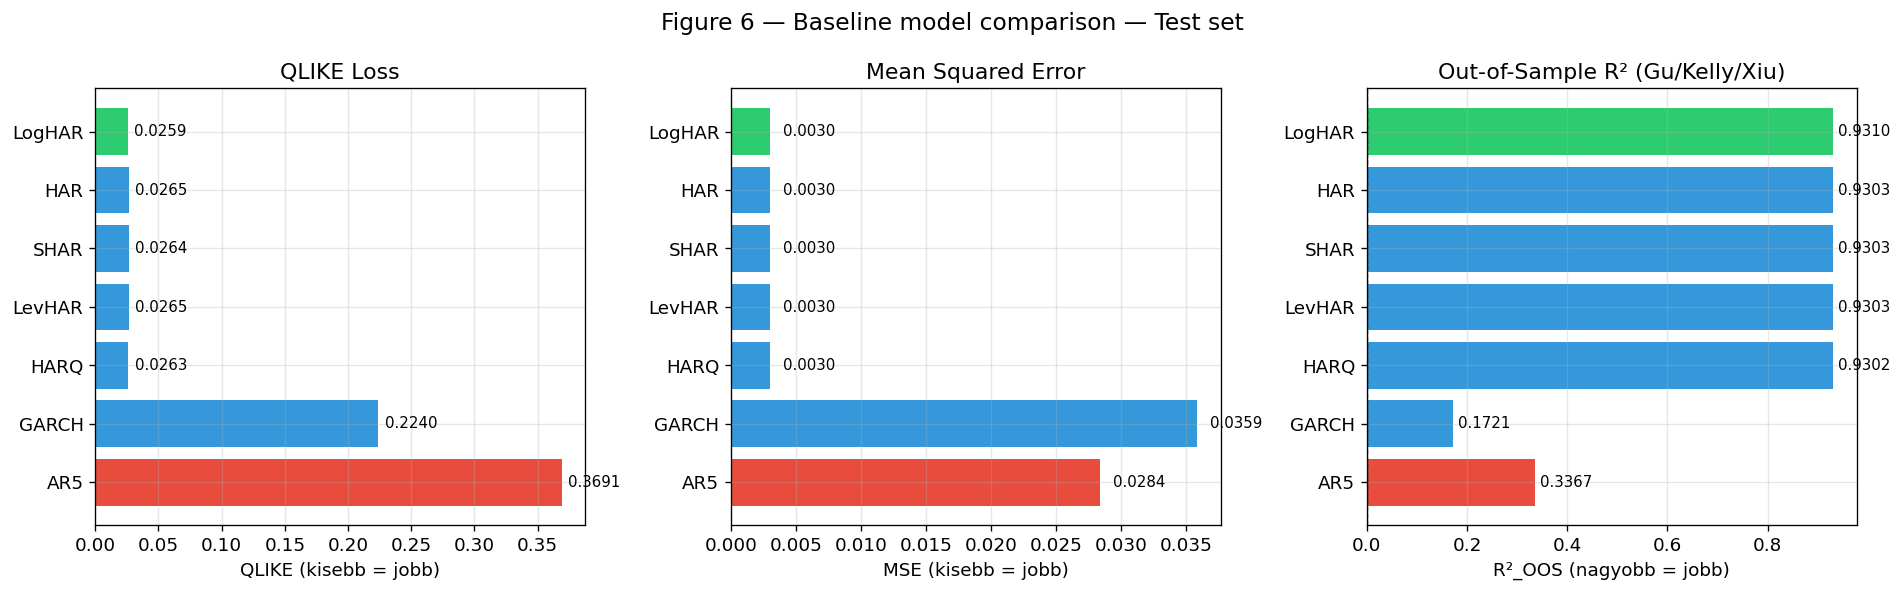

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [r["Model"] for r in rows]
colors = ["#2ecc71" if r["Model"] == "LogHAR" else "#3498db" if r["QLIKE"] < 0.25 else "#e74c3c" for r in rows]

# QLIKE
ax = axes[0]
vals = [r["QLIKE"] for r in rows]
bars = ax.barh(models, vals, color=colors)
ax.set_xlabel("QLIKE (kisebb = jobb)")
ax.set_title("QLIKE Loss")
ax.invert_yaxis()
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.4f}", va="center", fontsize=9)

# MSE
ax = axes[1]
vals = [r["MSE"] for r in rows]
bars = ax.barh(models, vals, color=colors)
ax.set_xlabel("MSE (kisebb = jobb)")
ax.set_title("Mean Squared Error")
ax.invert_yaxis()
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f"{v:.4f}", va="center", fontsize=9)

# R² OOS
ax = axes[2]
vals = [r["R²_OOS"] for r in rows]
bars = ax.barh(models, vals, color=colors)
ax.set_xlabel("R²_OOS (nagyobb = jobb)")
ax.set_title("Out-of-Sample R² (Gu/Kelly/Xiu)")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.invert_yaxis()
for bar, v in zip(bars, vals):
    offset = 0.01 if v >= 0 else -0.06
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2, f"{v:.4f}", va="center", fontsize=9)

fig.suptitle("Figure 6 — Baseline model comparison — Test set", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Actual vs Predicted Scatter Plots

Perfect forecasts sit on the red diagonal. Scatter below = underprediction, above = overprediction. Clipped to 99th percentile for visibility (extreme RV events excluded).

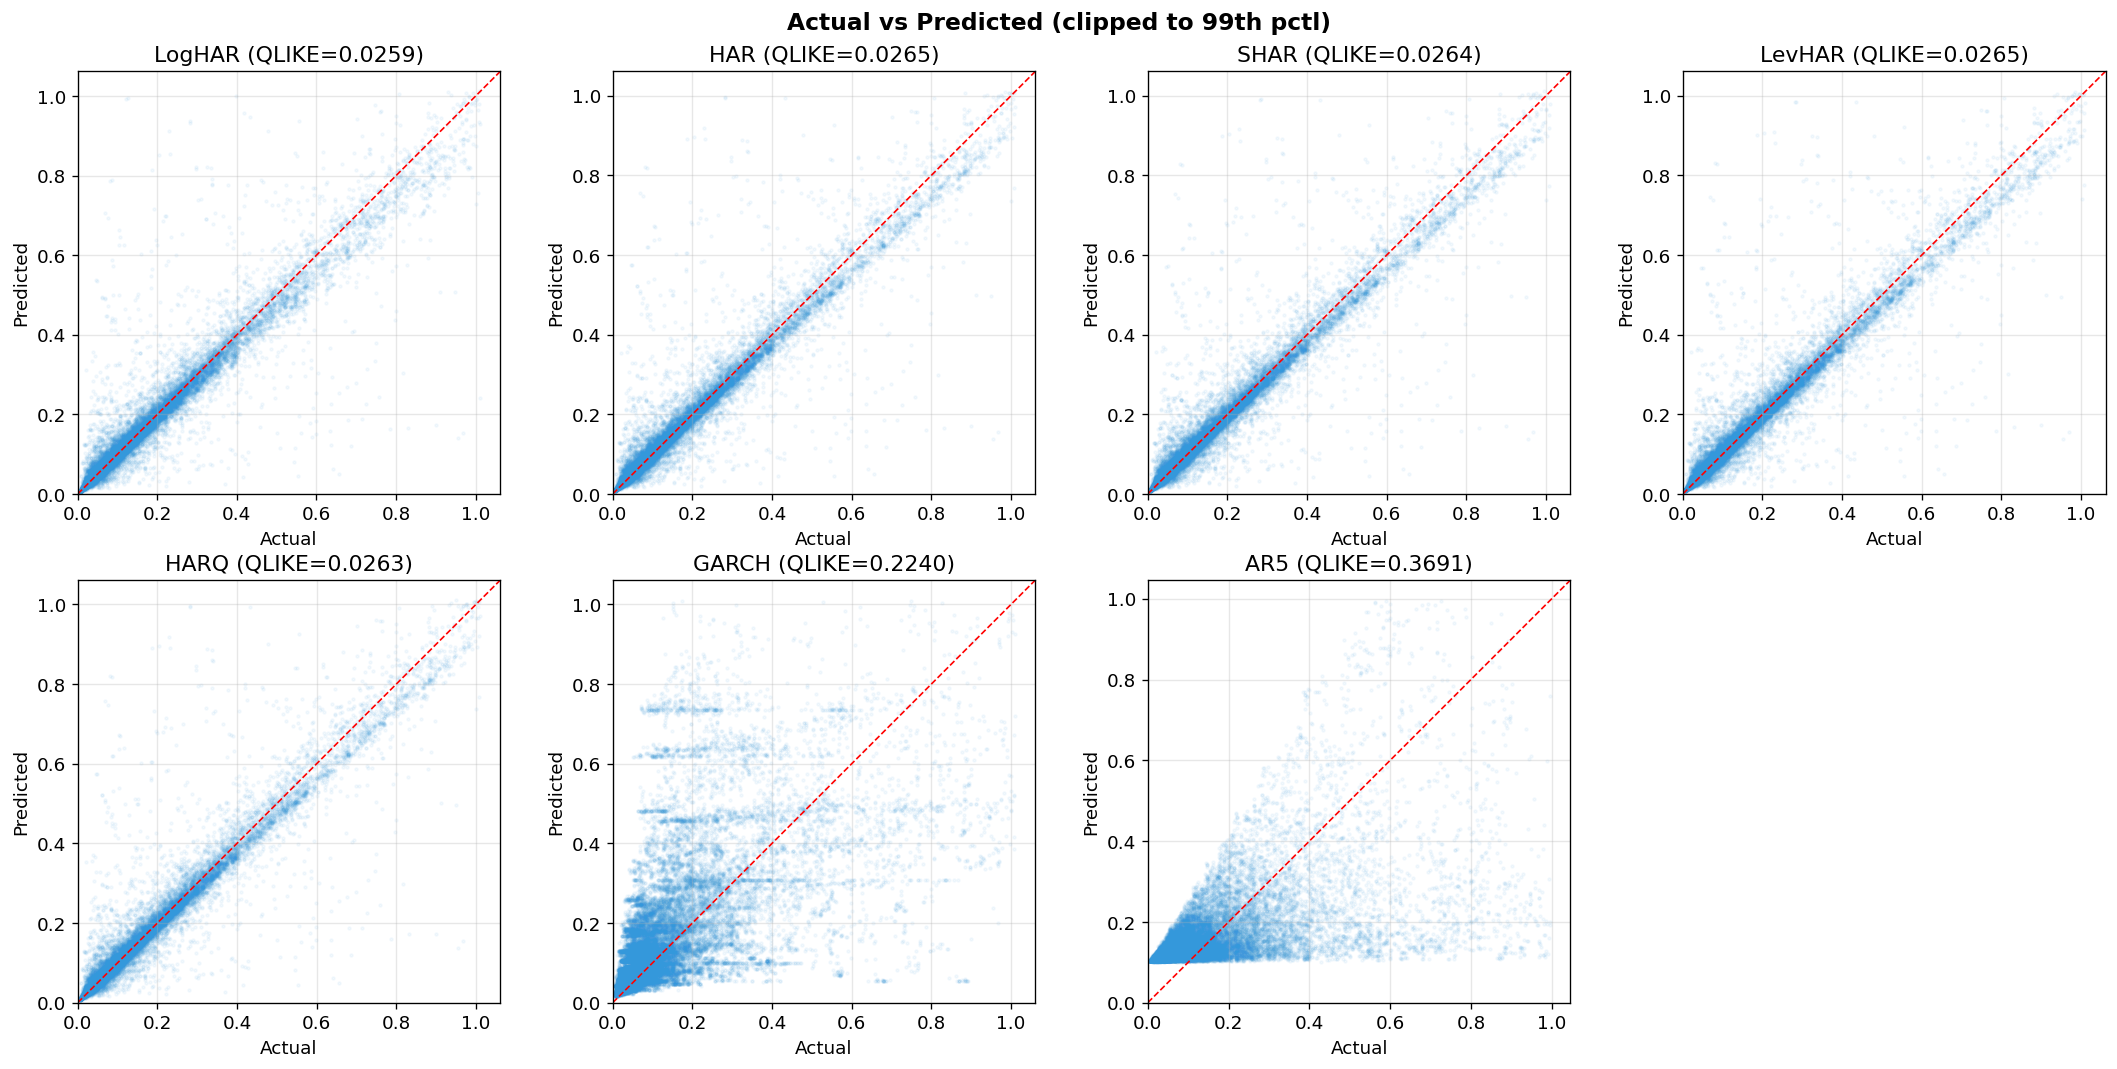

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flat

for i, name in enumerate(MODEL_ORDER):
    ax = axes[i]
    sub = preds.filter(pl.col("model") == name)
    y = sub["y_true"].to_numpy()
    yhat = sub["y_pred"].to_numpy()
    
    # Clip for visibility (99th percentile)
    clip = np.percentile(y, 99)
    mask = (y < clip) & (yhat < clip)
    
    ax.scatter(y[mask], yhat[mask], alpha=0.05, s=3, color="#3498db")
    lim = max(y[mask].max(), yhat[mask].max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", linewidth=1, label="perfect")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name} (QLIKE={qlike(y, yhat):.4f})")
    ax.set_aspect("equal")

# Hide unused subplot
axes[7].set_visible(False)

fig.suptitle("Actual vs Predicted (clipped to 99th pctl)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Time Series — Cross-Sectional Median Predictions

Daily median across all symbols — smooths out stock-specific noise, shows systematic bias over time. Three panels: top performers, HAR family overlap, and GARCH/AR5.

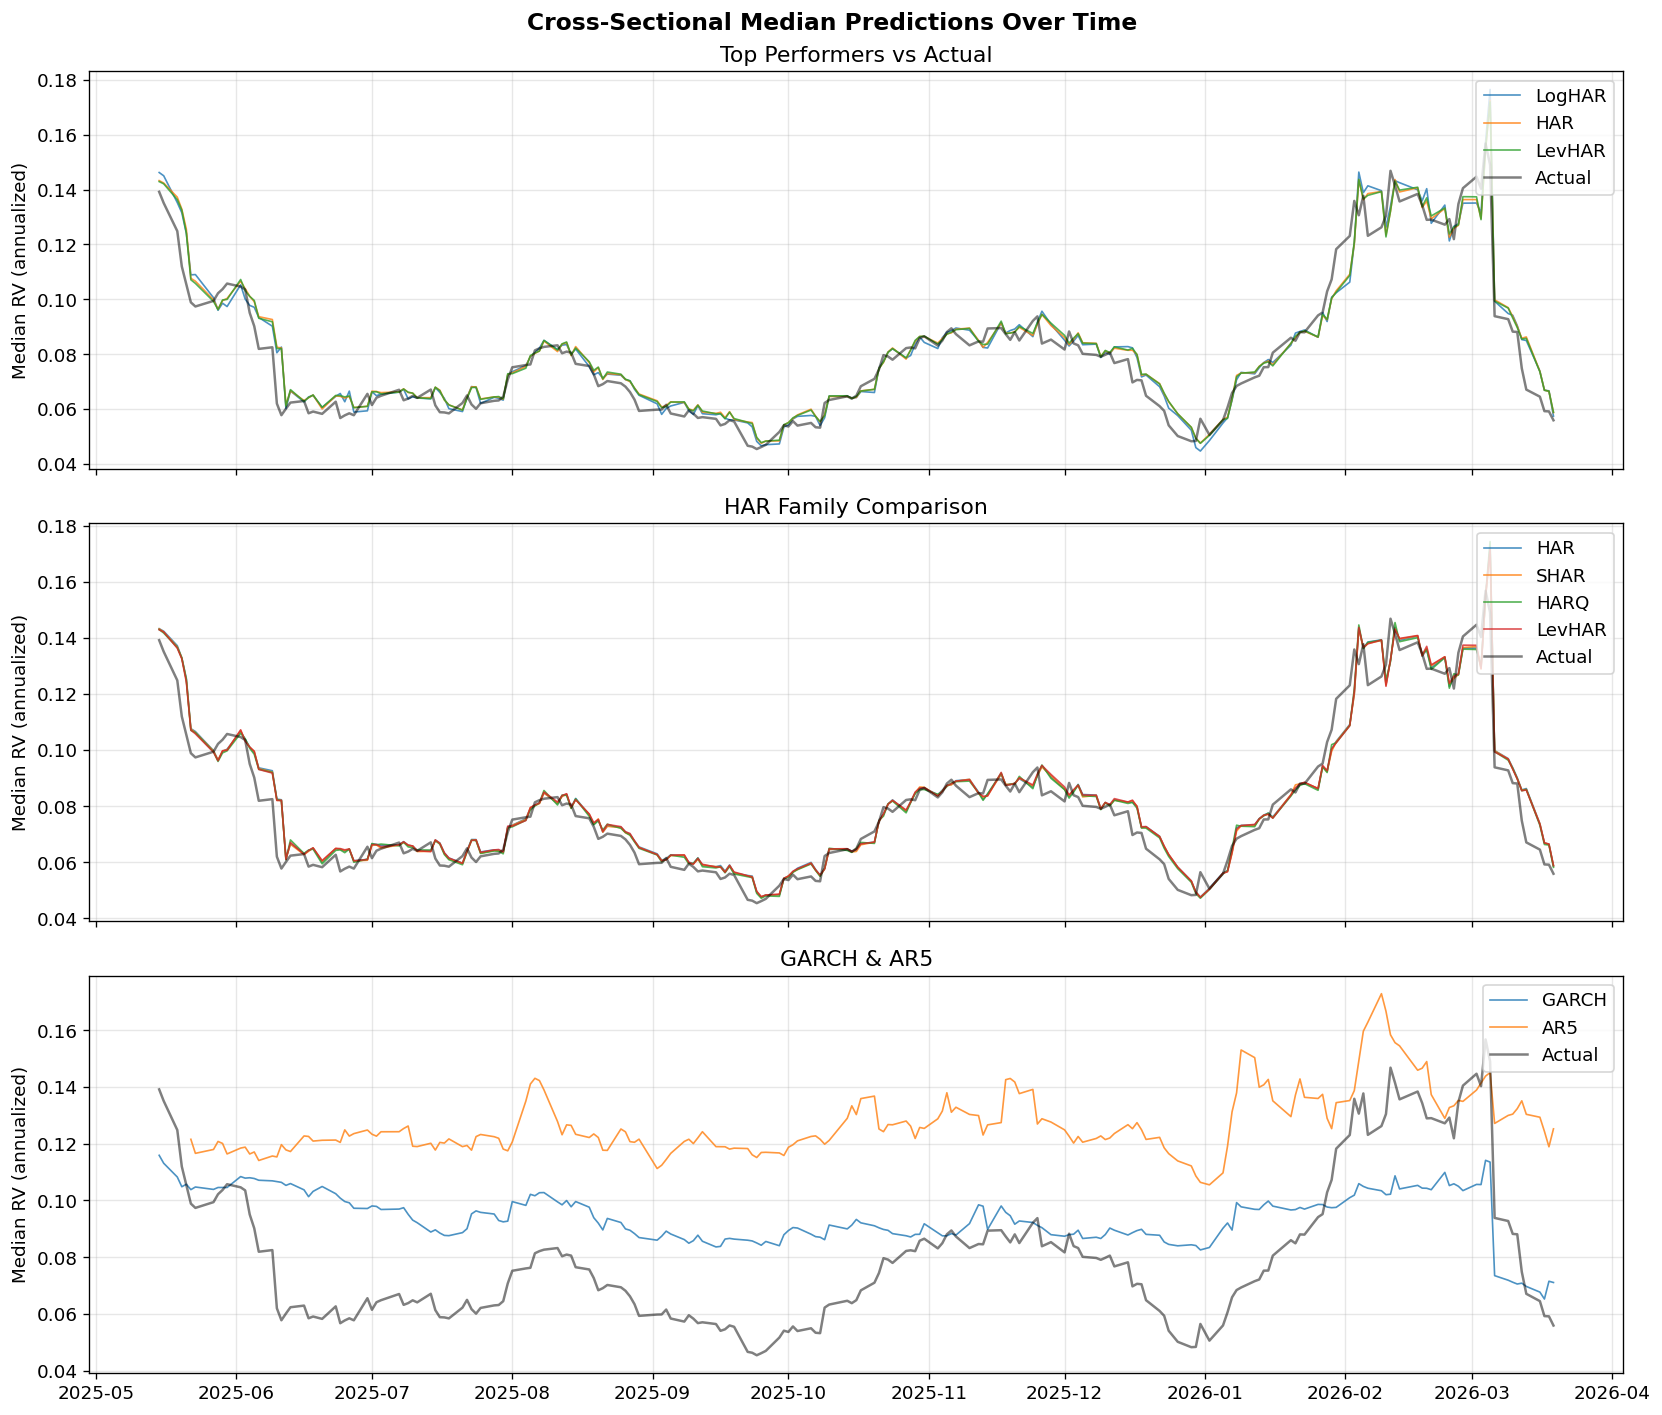

In [5]:
# Aggregate: median prediction per date per model
daily = preds.group_by(["model", "date"]).agg([
    pl.col("y_true").median().alias("median_true"),
    pl.col("y_pred").median().alias("median_pred"),
]).sort("date")

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top performers
ax = axes[0]
for name, color in [("LogHAR", "#2ecc71"), ("HAR", "#3498db"), ("LevHAR", "#9b59b6")]:
    sub = daily.filter(pl.col("model") == name)
    ax.plot(sub["date"].to_list(), sub["median_pred"].to_numpy(), label=name, alpha=0.8, linewidth=1)
actual = daily.filter(pl.col("model") == "HAR")
ax.plot(actual["date"].to_list(), actual["median_true"].to_numpy(), "k-", alpha=0.5, linewidth=1.5, label="Actual")
ax.set_ylabel("Median RV (annualized)")
ax.set_title("Top Performers vs Actual")
ax.legend(loc="upper right")

# HAR family
ax = axes[1]
for name, color in [("HAR", "#3498db"), ("SHAR", "#e67e22"), ("HARQ", "#1abc9c"), ("LevHAR", "#9b59b6")]:
    sub = daily.filter(pl.col("model") == name)
    ax.plot(sub["date"].to_list(), sub["median_pred"].to_numpy(), label=name, alpha=0.8, linewidth=1)
ax.plot(actual["date"].to_list(), actual["median_true"].to_numpy(), "k-", alpha=0.5, linewidth=1.5, label="Actual")
ax.set_ylabel("Median RV (annualized)")
ax.set_title("HAR Family Comparison")
ax.legend(loc="upper right")

# Worst performers
ax = axes[2]
for name, color in [("GARCH", "#e74c3c"), ("AR5", "#95a5a6")]:
    sub = daily.filter(pl.col("model") == name)
    ax.plot(sub["date"].to_list(), sub["median_pred"].to_numpy(), label=name, alpha=0.8, linewidth=1)
ax.plot(actual["date"].to_list(), actual["median_true"].to_numpy(), "k-", alpha=0.5, linewidth=1.5, label="Actual")
ax.set_ylabel("Median RV (annualized)")
ax.set_title("GARCH & AR5")
ax.legend(loc="upper right")

fig.suptitle("Cross-Sectional Median Predictions Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Single Symbol Deep Dive

Change `SYMBOL` to inspect any ticker. Shows predictions vs actual and forecast errors over time for LogHAR, HAR, and GARCH.

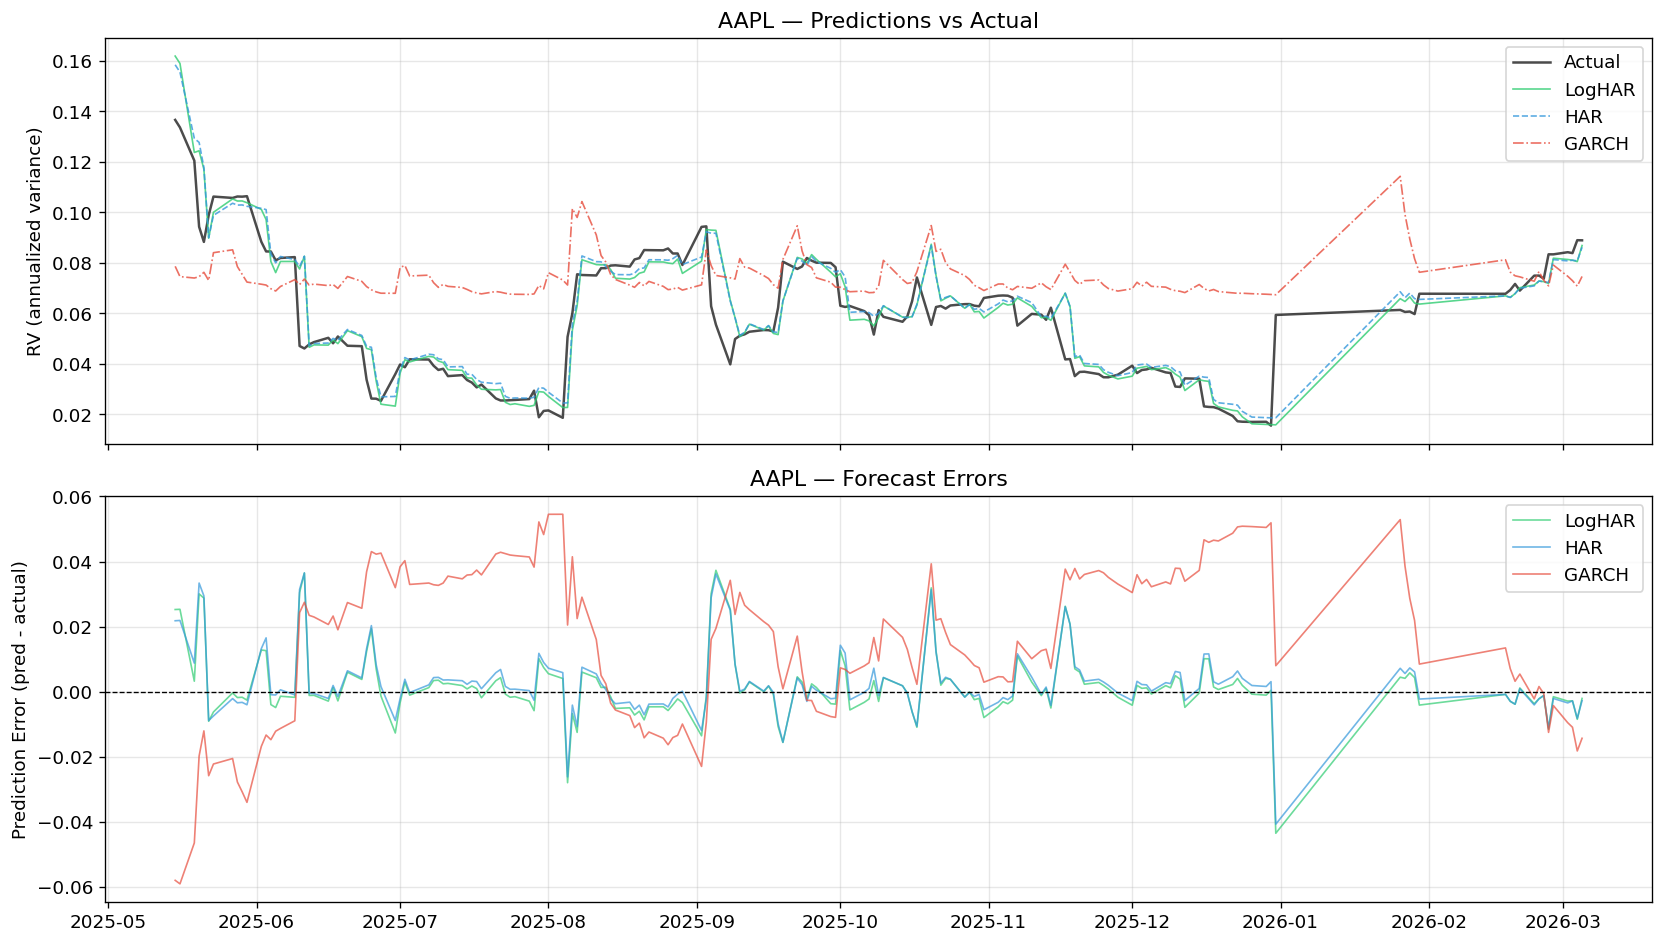

In [6]:
SYMBOL = "AAPL"  # change to any symbol

sym_preds = preds.filter(pl.col("symbol") == SYMBOL).sort("date")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Predictions
ax = axes[0]
actual_sub = sym_preds.filter(pl.col("model") == "HAR")
ax.plot(actual_sub["date"].to_list(), actual_sub["y_true"].to_numpy(), "k-", linewidth=1.5, label="Actual", alpha=0.7)

for name, ls, color in [
    ("LogHAR", "-", "#2ecc71"), ("HAR", "--", "#3498db"),
    ("GARCH", "-.", "#e74c3c"),
]:
    sub = sym_preds.filter(pl.col("model") == name)
    ax.plot(sub["date"].to_list(), sub["y_pred"].to_numpy(), ls, color=color, label=name, alpha=0.8, linewidth=1)

ax.set_ylabel("RV (annualized variance)")
ax.set_title(f"{SYMBOL} — Predictions vs Actual")
ax.legend(loc="upper right")

# Prediction errors
ax = axes[1]
for name, color in [("LogHAR", "#2ecc71"), ("HAR", "#3498db"), ("GARCH", "#e74c3c")]:
    sub = sym_preds.filter(pl.col("model") == name)
    errors = sub["y_pred"].to_numpy() - sub["y_true"].to_numpy()
    ax.plot(sub["date"].to_list(), errors, label=name, alpha=0.7, linewidth=1, color=color)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Prediction Error (pred - actual)")
ax.set_title(f"{SYMBOL} — Forecast Errors")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 6. Residual Distributions

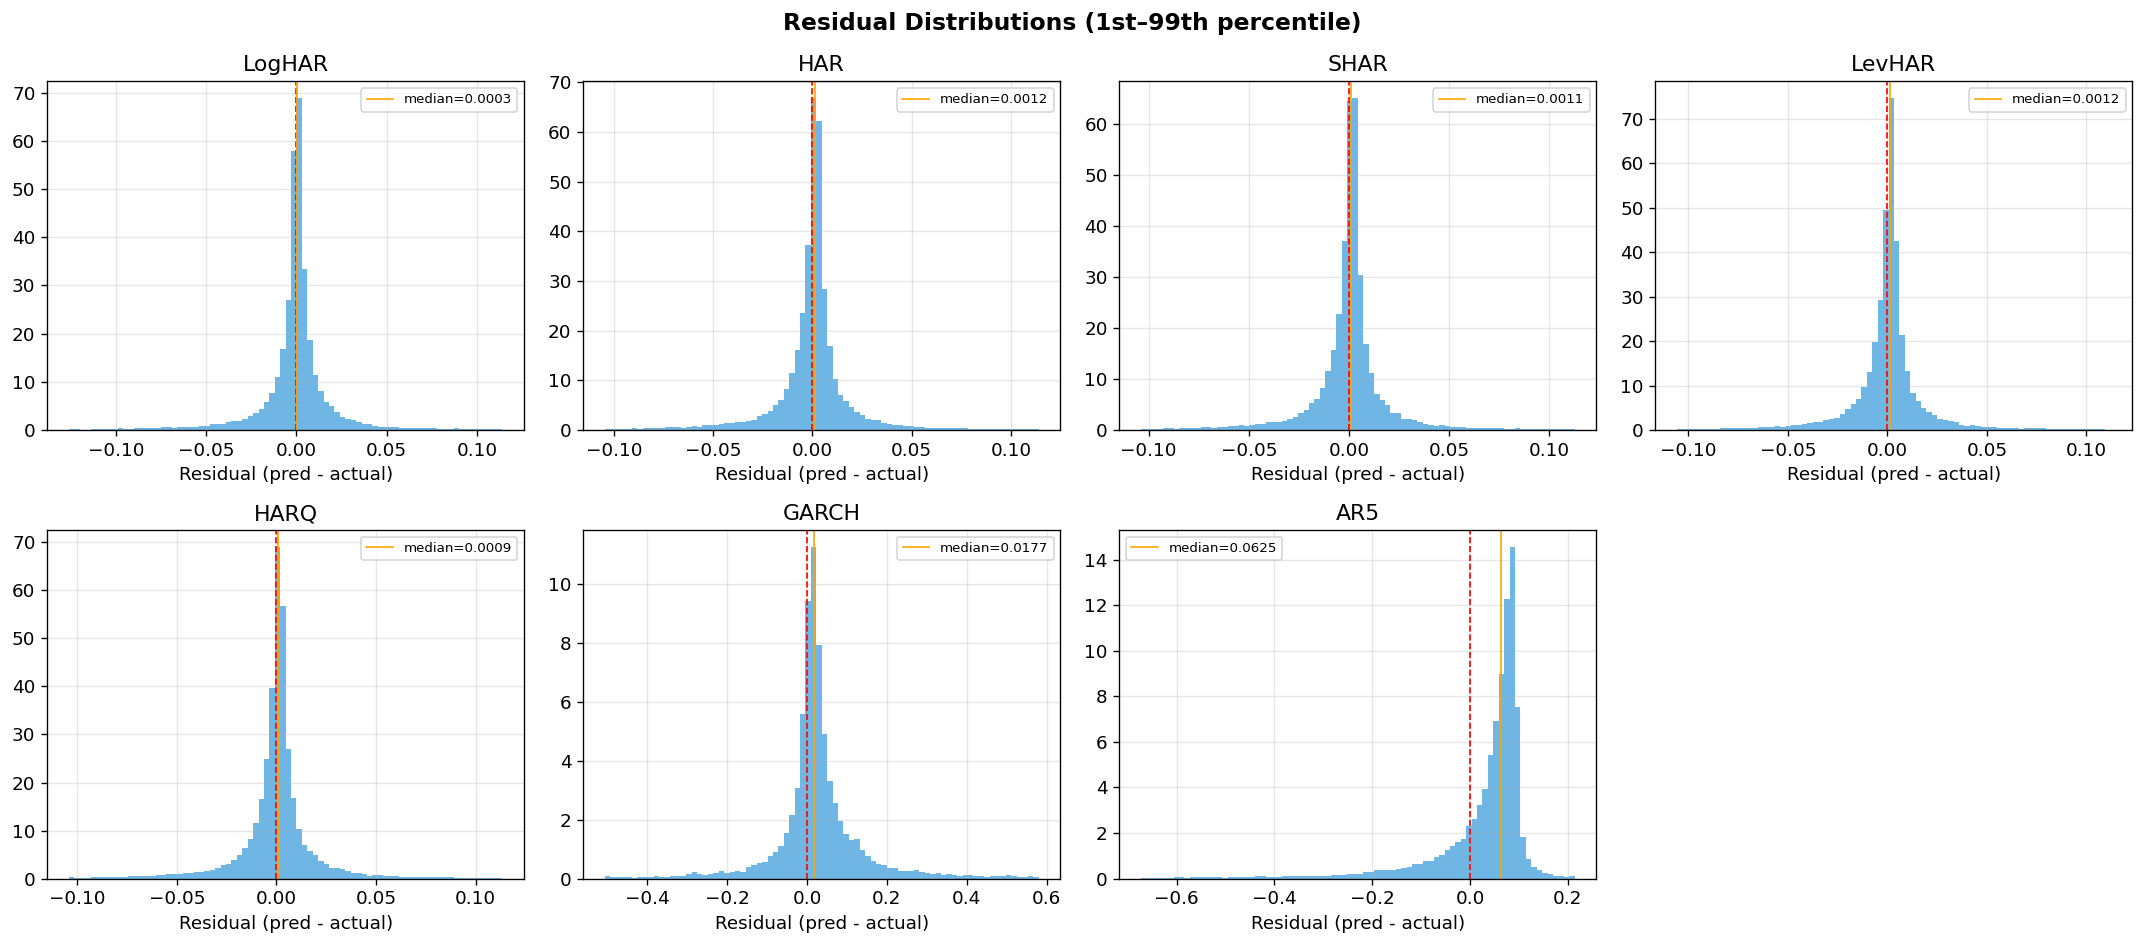

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flat

for i, name in enumerate(MODEL_ORDER):
    ax = axes[i]
    sub = preds.filter(pl.col("model") == name)
    residuals = sub["y_pred"].to_numpy() - sub["y_true"].to_numpy()
    
    # Clip to 1st/99th pctl for visibility
    lo, hi = np.percentile(residuals, [1, 99])
    clipped = residuals[(residuals >= lo) & (residuals <= hi)]
    
    ax.hist(clipped, bins=80, density=True, alpha=0.7, color="#3498db")
    ax.axvline(0, color="red", linewidth=1, linestyle="--")
    ax.axvline(np.median(residuals), color="orange", linewidth=1, linestyle="-", label=f"median={np.median(residuals):.4f}")
    ax.set_title(name)
    ax.set_xlabel("Residual (pred - actual)")
    ax.legend(fontsize=8)

axes[7].set_visible(False)

fig.suptitle("Residual Distributions (1st–99th percentile)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. QLIKE by Symbol — Who Struggles?

Per-symbol QLIKE for HAR and LogHAR. Identifies problematic stocks (thin chains, extreme events) and strongest performers. Worst/best 15 shown.

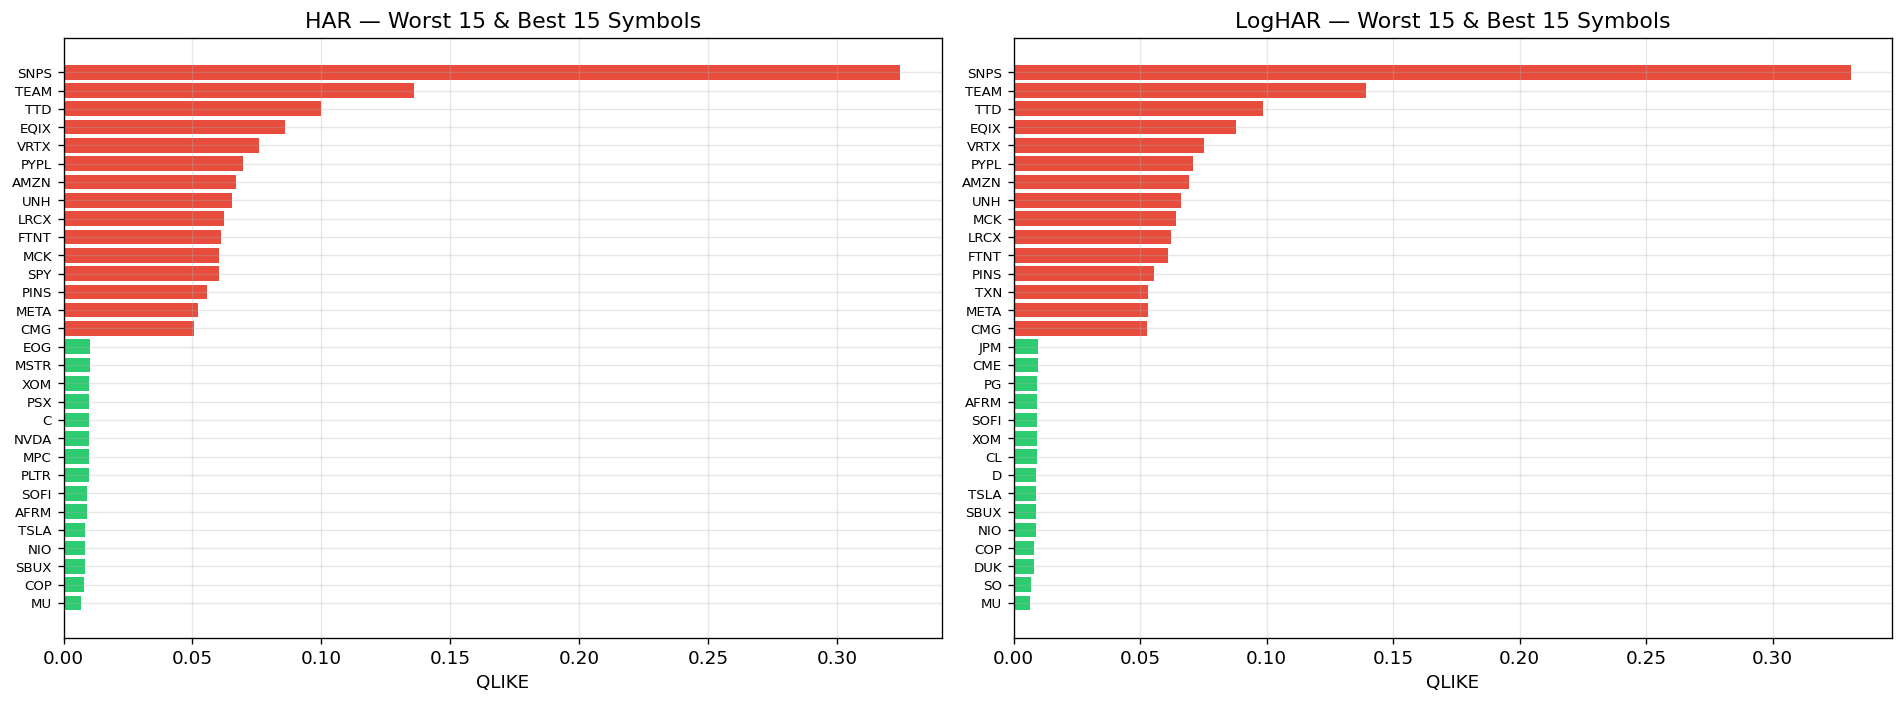


HAR per-symbol QLIKE: median=0.0202, mean=0.0269, std=0.0276, worst=0.3246 (SNPS)

LogHAR per-symbol QLIKE: median=0.0200, mean=0.0262, std=0.0282, worst=0.3307 (SNPS)


In [8]:
# Per-symbol QLIKE for HAR and LogHAR
symbol_qlike = []
for name in ["HAR", "LogHAR"]:
    sub = preds.filter(pl.col("model") == name)
    for sym in sub["symbol"].unique().sort().to_list():
        s = sub.filter(pl.col("symbol") == sym)
        y = s["y_true"].to_numpy()
        yhat = s["y_pred"].to_numpy()
        if len(y) > 0 and np.all(yhat > 0):
            symbol_qlike.append({"symbol": sym, "model": name, "qlike": qlike(y, yhat), "n": len(y)})

sq = pl.DataFrame(symbol_qlike)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, name in enumerate(["HAR", "LogHAR"]):
    ax = axes[i]
    sub = sq.filter(pl.col("model") == name).sort("qlike", descending=True)
    syms = sub["symbol"].to_list()
    vals = sub["qlike"].to_numpy()
    
    # Show worst 20 and best 20
    worst = sub.head(15)
    best = sub.tail(15)
    show = pl.concat([worst, best])
    
    colors = ["#e74c3c"] * len(worst) + ["#2ecc71"] * len(best)
    ax.barh(show["symbol"].to_list(), show["qlike"].to_numpy(), color=colors)
    ax.set_xlabel("QLIKE")
    ax.set_title(f"{name} — Worst 15 & Best 15 Symbols")
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

# Summary stats
for name in ["HAR", "LogHAR"]:
    sub = sq.filter(pl.col("model") == name)
    print(f"\n{name} per-symbol QLIKE: median={sub['qlike'].median():.4f}, "
          f"mean={sub['qlike'].mean():.4f}, std={sub['qlike'].std():.4f}, "
          f"worst={sub['qlike'].max():.4f} ({sub.sort('qlike', descending=True)[0, 'symbol']})")

## 8. Prediction Coverage Check

Row counts and date alignment across models. LogHAR and AR5 have fewer rows (zero-RV filtering and lag dropout). The common (symbol, date) intersection is needed for Phase 7 Diebold-Mariano pairwise tests.

In [9]:
print(f"{'Model':8s}  {'Rows':>7s}  {'Symbols':>7s}  {'Dates':>6s}  {'Min Date':>12s}  {'Max Date':>12s}  {'NaN pred':>8s}  {'Neg pred':>8s}")
print("-" * 80)
for name in MODEL_ORDER:
    sub = preds.filter(pl.col("model") == name)
    print(f"{name:8s}  {len(sub):7,}  {sub['symbol'].n_unique():7}  {sub['date'].n_unique():6}  "
          f"{sub['date'].min()}  {sub['date'].max()}  "
          f"{sub['y_pred'].is_nan().sum():8}  {(sub['y_pred'].to_numpy() < 0).sum():8}")

# Common rows across all models
common_keys = None
for name in MODEL_ORDER:
    sub = preds.filter(pl.col("model") == name).select("symbol", "date")
    keys = set(zip(sub["symbol"].to_list(), sub["date"].to_list()))
    common_keys = keys if common_keys is None else common_keys & keys

print(f"\nCommon (symbol, date) pairs across all 7 models: {len(common_keys):,}")
print(f"(Use this intersection for DM tests in Phase 7)")

Model        Rows  Symbols   Dates      Min Date      Max Date  NaN pred  Neg pred
--------------------------------------------------------------------------------
LogHAR     36,811      192     210  2025-05-15  2026-03-19         0         0
HAR        36,924      192     210  2025-05-15  2026-03-19         0         0
SHAR       36,924      192     210  2025-05-15  2026-03-19         0         0
LevHAR     36,924      192     210  2025-05-15  2026-03-19         0         0
HARQ       36,924      192     210  2025-05-15  2026-03-19         0         0
GARCH      36,924      192     210  2025-05-15  2026-03-19         0         0
AR5        35,964      192     205  2025-05-22  2026-03-19         0         0



Common (symbol, date) pairs across all 7 models: 35,855
(Use this intersection for DM tests in Phase 7)
